# Overview

This script does .... [place holder]

## Running to do list

1. for merged_df - check if any of the values between plopp/flopp have non-null values for spectra? answers question are the wavenlength values exclusive between targets? 
2. If yes, perhaps there is a better way to export using a python package for .spas? 
3. 





In [3]:
import os
import sys
import pandas as pd
import xgboost as xgb
import numpy as np
from xgboost import plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

from scipy.signal import savgol_filter
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import GradientBoostingClassifier

# increase the decimal places in all columns 
pd.options.display.float_format = '{:.6f}'.format

# 1. Load Data and Preprocess

We first combine the separate FLOPP and PLOPP datasets; add target columsn, and then merge into our training dataset. 

**PLOPP**: Currently there are 936 columns and 237 rows, representing 237 individual spectra (?) from individual csv files. 

**FLOPP**: Currently there are x columns and y rows, representing z individual spectra (?) from individual csv files. 

## to do list: 
1. data merging - disregard SPA files 
2. cut from PLOPP list (remove names/csvs)
4/24/24: use the 

## PLOPP

In [ ]:
print(os.getcwd())


/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/spectra_analysis_work/analysis/src


In [3]:
# Combine all the CSVs into one merged PLOPP dataset

def process_csv_files(directory):
    data_frames = []

    for filename in os.listdir(directory):
        if filename.lower().endswith('.csv'):  
            file_path = os.path.join(directory, filename) 

            df = pd.read_csv(file_path, header=None, names=['Wavelength', 'Datavalue'])
            df_transposed = df.set_index('Wavelength').T
            df_transposed['Sample'] = filename

            data_frames.append(df_transposed)

    master_df = pd.concat(data_frames, axis=0).fillna(0)

    return master_df

directory = "../../../../CSV Files/PLOPP/CSV Files"




plopp_df = process_csv_files(directory)

plopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in plopp_df.columns]

plopp_df['Target'] = "PLOPP"

plopp_df.to_csv("../../../../CSV Files/PLOPP/plopp_merged.csv", index=False)



# Print the master DataFrame for review
plopp_df
print(plopp_df.shape)



(263, 938)


In [4]:
plopp_df.head()

,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.817920,91.799890,91.768400,91.759260,91.803400,91.885330,91.895230,0.000000,54c.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.245870,97.219830,97.283520,97.345570,97.343240,97.352390,97.383830,0.000000,23a.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.535050,91.539890,91.538020,91.560490,91.593530,91.580960,91.587860,0.000000,74a.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.119210,92.109000,92.050710,92.068950,92.132290,92.172480,92.242130,0.000000,78b.CSV,PLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,94.578730,94.567590,94.558040,94.586940,94.629390,94.671810,94.684270,0.000000,9a.CSV,PLOPP


## FLOPP

In [5]:
directory = "../../../../CSV Files/FLOPP/8 cm -1 resolution CORRECT"

flopp_df = process_csv_files(directory)
flopp_df.columns = ['wavelength_' + str(col) if col not in ['Sample'] else col for col in flopp_df.columns]

flopp_df['Target'] = "FLOPP"

#flopp_df.to_csv("../../CSV Files/FLOPP/Flopp_merged.csv", index=False)


print(flopp_df.shape)
# Print the master DataFrame for review
flopp_df


(186, 938)


,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLOPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.188320,99.233940,99.190930,99.225070,99.156200,99.293390,99.180210,0.000000,PEVA 10_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,97.601630,97.646840,97.662280,97.705030,97.718460,97.702880,97.682560,0.000000,Polyester 10_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.619910,99.624230,99.595730,99.585510,99.593260,99.630400,99.604730,0.000000,PLA 9_8cm.CSV,FLOPP
Datavalue,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,99.648720,99.642620,99.626400,99.630580,99.635880,99.643420,99.582090,0.000000,PU 6_8 cm.CSV,FLOPP


## Merging


In [6]:
flopps_cols = flopp_df.columns
plopp_cols = plopp_df.columns

# print out the column elements

merged_cols = [i for i in plopp_cols if i in flopps_cols]

In [7]:
result_df = pd.concat([flopp_df, plopp_df], axis=0, ignore_index=True)


In [8]:
result_df

,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,FLOPP
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,FLOPP
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,FLOPP
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,FLOPP
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,FLOPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.000130,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,PLOPP
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.101600,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,PLOPP
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.348060,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,PLOPP
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.008270,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,PLOPP


In [9]:
result_df.to_csv("../../data/output/merged_df.csv")

In [10]:
# train a xgboost model on this data, predicting based on Library

result_df['Target'] = result_df['Target'].map({'FLOPP': 0, 'PLOPP': 1})

features = result_df.drop(['Target', 'Sample'], axis=1)
target = result_df['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)



def standard_normal_variate(X):
    # Mean centering
    mean_centered = X - np.mean(X, axis=1, keepdims=True)
    # Scaling to unit variance
    snv_transformed = mean_centered / np.std(mean_centered, axis=1, keepdims=True)
    return snv_transformed



def calculate_derivatives(data, window_length, polyorder, deriv=1):
    """
    Calculate derivatives using Savitzky-Golay filter.
    :param data: Input data array
    :param window_length: The length of the filter window (must be odd number)
    :param polyorder: The order of the polynomial used to fit the samples
    :param deriv: Order of the derivative to compute (1 for first, 2 for second)
    :return: Derivative of the data
    """
    return savgol_filter(data, window_length, polyorder, deriv=deriv)

class SNVTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, use_scaling=True):
        self.use_scaling = use_scaling

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        mean_centered = X - np.mean(X, axis=1, keepdims=True)
        if self.use_scaling:
            return mean_centered / np.std(mean_centered, axis=1, keepdims=True)
        return mean_centered


class DerivativeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=11, polyorder=2, deriv=1):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Ensure input is a numpy array
        X = np.array(X)
        # Apply the derivative transformation
        transformed = np.apply_along_axis(calculate_derivatives, axis=1, arr=X,
                                          window_length=self.window_length, 
                                          polyorder=self.polyorder, deriv=self.deriv)
        return transformed




# Assuming SNVTransformer and DerivativeTransformer have been defined as per previous instructions

pipeline = Pipeline([
    ('snv', SNVTransformer()),
    ('derivatives', DerivativeTransformer()),
    ('classifier', XGBClassifier())
])

param_grid = {
    'snv__use_scaling': [True, False],   # Example parameter for SNVTransformer
   # 'derivatives__window_length': [7, 11, 15],
   # 'derivatives__polyorder': [2, 3],
    'derivatives__deriv': [0, 1, 2],
    'classifier__n_estimators': [100, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 6, 9]
}


# Define GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', verbose=1)

# Fit GridSearchCV
# Assuming X_train and y_train are your data and labels
grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score (F1): {:.3f}".format(grid_search.best_score_))



Training data shape: (269, 936)
Testing data shape: (180, 936)
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}
Best cross-validation score (F1): 0.979


In [11]:
result_df = pd.read_csv("/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/spectra_analysis_work/merged_df.csv")
result_df = result_df.drop(['Unnamed: 0'], axis=1)
result_df['Target'] = result_df['Target'].map({'FLOPP': 0, 'PLOPP': 1})

result_df

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jacobford/Dropbox/Received from Jacob Ford - random forest modeling/spectra_analysis_work/merged_df.csv'

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Load the Breast Cancer dataset

X, y = result_df.drop(['Target', 'Sample'], axis=1), result_df.Target

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Creating and training the Logistic Regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predicting the test set results
y_pred = model.predict(X_test)

# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9611111111111111
Precision: 0.9428571428571428
Recall: 0.99
F1 Score: 0.9658536585365853


False Positive Rate: 0.07
False Negative Rate: 0.01
True Positive Rate: 0.99
True Negative Rate: 0.93


Text(0.5, 1.0, 'Confusion Matrix')

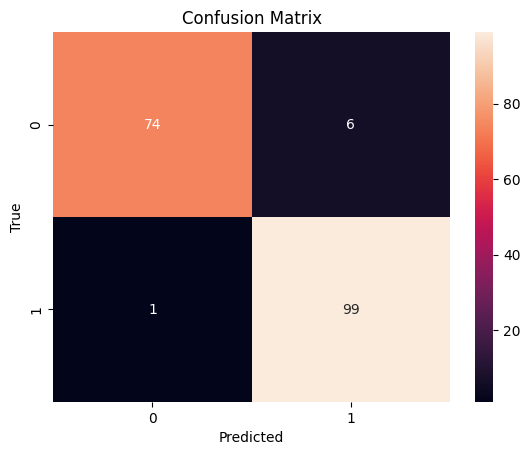

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)
true_positive_rate = tp / (tp + fn)
true_negative_rate = tn / (tn + fp)

print(f"False Positive Rate: {false_positive_rate:.2f}")
print(f"False Negative Rate: {false_negative_rate:.2f}")
print(f"True Positive Rate: {true_positive_rate:.2f}")
print(f"True Negative Rate: {true_negative_rate:.2f}")

fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

# save the confusion matrix as a png:
#plt.savefig('confusion_matrix.png')

# 2. Model Training


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', verbose=1)

# Fit GridSearchCV
# Assuming X_train and y_train are your data and labels
grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score (F1): {:.3f}".format(grid_search.best_score_))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'derivatives__deriv': 1, 'snv__use_scaling': True}
Best cross-validation score (F1): 0.979


In [ ]:
# train a xgboost model on this data, predicting based on Library

result_df['Target'] = result_df['Target'].map({'FLOPP': 0, 'PLOPP': 1})

features = result_df.drop(['Target', 'Sample'], axis=1)
target = result_df['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.4, random_state=42)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)


Training data shape: (269, 936)
Testing data shape: (180, 936)


In [ ]:
result_df

,wavelength_397.2809,wavelength_401.138,wavelength_404.9951,wavelength_408.8522,wavelength_412.7093,wavelength_416.5664,wavelength_420.4235,wavelength_424.2805,wavelength_428.1377,wavelength_431.9948,...,wavelength_3976.666,wavelength_3980.523,wavelength_3984.38,wavelength_3988.237,wavelength_3992.094,wavelength_3995.951,wavelength_3999.809,wavelength_4003.666,Sample,Target
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.040790,98.064640,98.072340,98.090140,98.065730,98.030320,98.040350,0.000000,PE 12_8cm.CSV,NaN
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.498280,98.516020,98.449390,98.543720,98.516090,98.505090,98.499170,0.000000,ABS12_8cm.CSV,NaN
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,104.306700,104.303800,104.309200,104.332100,104.467600,104.351000,104.341500,0.000000,Nylon 5_8cm.CSV,NaN
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101.102700,101.123400,101.041400,101.108400,101.113200,101.091900,101.109900,0.000000,PET 2_8cm.CSV,NaN
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,98.888720,99.043970,98.959140,98.883790,98.834790,99.027960,99.004300,0.000000,Acrylic5_8cm.CSV,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,96.000130,96.019650,95.995780,95.956410,95.981160,96.036570,96.074420,0.000000,41b.CSV,NaN
445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,100.101600,100.126900,100.160900,100.165200,100.168700,100.168900,100.157700,0.000000,82c.CSV,NaN
446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,91.348060,91.368650,91.401120,91.413200,91.408660,91.441210,91.456630,0.000000,6c.CSV,NaN
447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,93.008270,92.958400,92.905300,92.870000,92.903980,92.938250,92.967780,0.000000,16b.CSV,NaN


In [ ]:
model = xgb.XGBClassifier(objective='binary:logistic', seed=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 92.78%


# 3. Model Evaluation

## Confusion Matrix

False Positive Rate: 0.15
False Negative Rate: 0.01
True Positive Rate: 0.99
True Negative Rate: 0.85


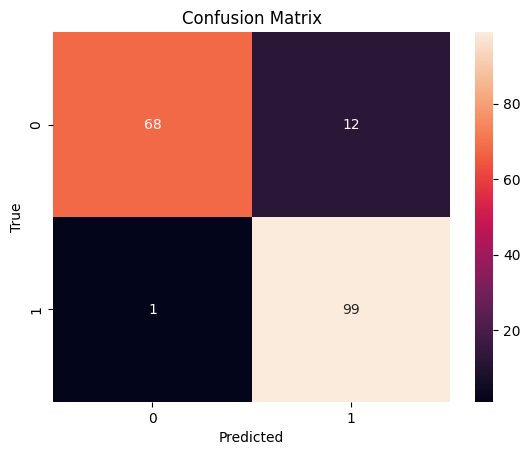

In [ ]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)
true_positive_rate = tp / (tp + fn)
true_negative_rate = tn / (tn + fp)

print(f"False Positive Rate: {false_positive_rate:.2f}")
print(f"False Negative Rate: {false_negative_rate:.2f}")
print(f"True Positive Rate: {true_positive_rate:.2f}")
print(f"True Negative Rate: {true_negative_rate:.2f}")

fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='g', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')

# save the confusion matrix as a png:
plt.savefig('confusion_matrix.png')

## Feature Importance

### Direct Contribution Strength

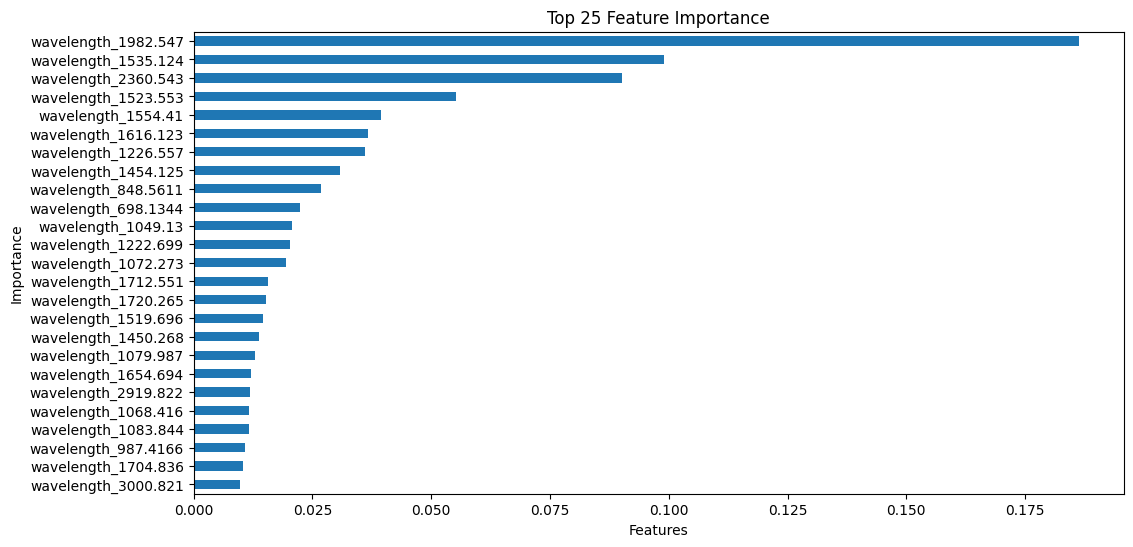

In [ ]:
feature_importances = model.feature_importances_

feature_names = X_train.columns

importances_series = pd.Series(feature_importances, index=feature_names)

top_ten_importances = importances_series.sort_values(ascending=True)[-25:]


top_ten_importances.plot(kind='barh', figsize=(12,6))
plt.title("Top 25 Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Features")


# save the feature importances as a png:
plt.savefig('feature_importances_method1.png')

plt.show()

### F Score

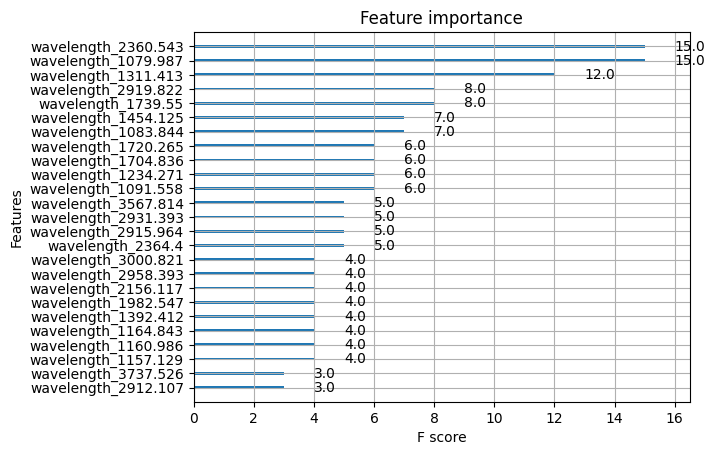

In [ ]:
fig, ax = plt.subplots() 
plot_importance(model, ax=ax, max_num_features=25) 


plt.savefig('feature_importances_method2_fscore.png')

plt.show()  


### Shap Values

In [ ]:
# give me the average of this variable, but in a two way table by Target
result_df.groupby('Target')['wavelength_1982.547'].mean()

#result_df['wavelength_1982.547'].mean()

Target
0   99.518395
1   93.660182
Name: wavelength_1982.547, dtype: float64

In [ ]:
result_df.groupby('Target')['wavelength_2360.543'].mean()


Target
0   101.415472
1    94.607187
Name: wavelength_2360.543, dtype: float64

In [ ]:
result_df.groupby('Target')['wavelength_1091.558'].mean()


Target
0   83.412308
1   78.650883
Name: wavelength_1091.558, dtype: float64

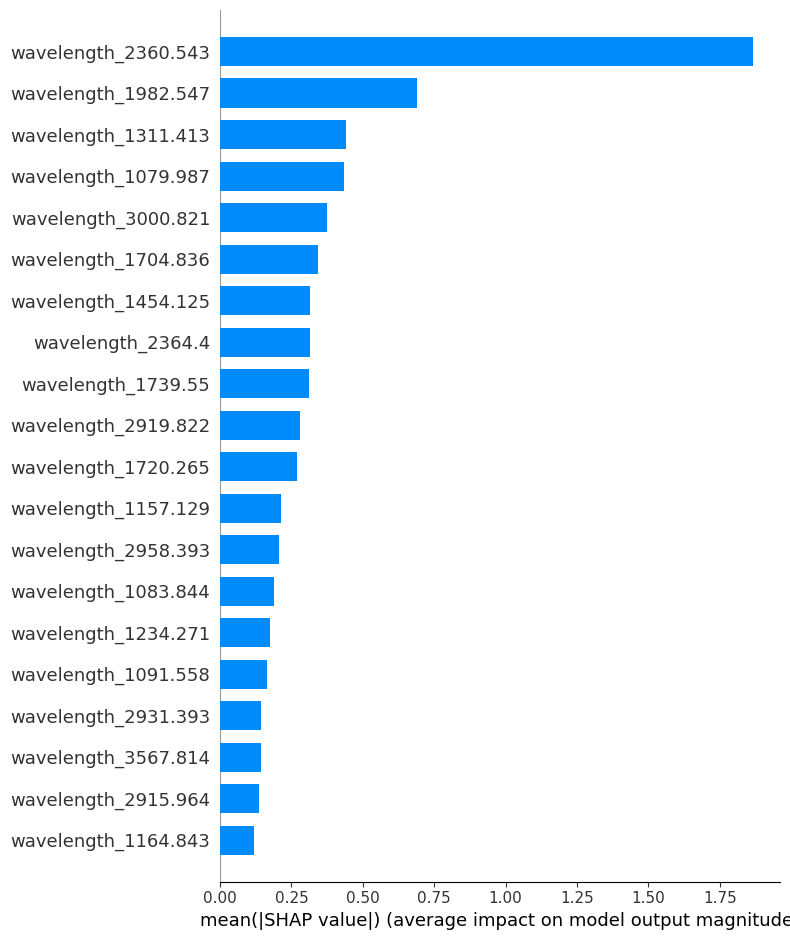

<Figure size 640x480 with 0 Axes>

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

fig, ax = plt.subplots(figsize=(10, 8))
# add title to shap

shap.summary_plot(shap_values, X_train, plot_type="bar", title="test")


plt.savefig('feature_importances_method3_shap.png')

plt.show()


## Distribution Graph

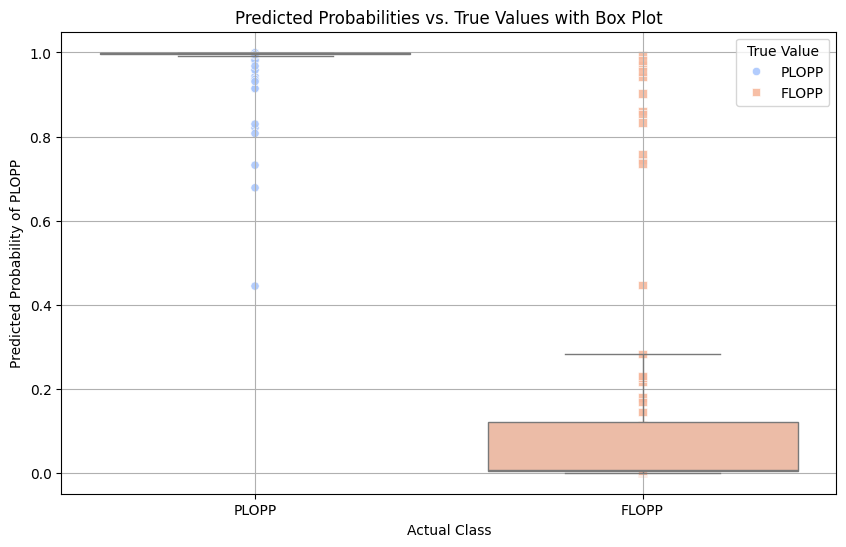

In [ ]:
# Get predicted probabilities for class 1
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_proba

plot_data = pd.DataFrame({
    'Predicted Probability': y_pred_proba,
    'Actual Class': y_test
})

# Convert 'Actual Class' to a categorical type and rename categories
plot_data['Actual Class'] = pd.Categorical(plot_data['Actual Class'])
plot_data['Actual Class'] = plot_data['Actual Class'].cat.rename_categories({'0': 'FLOPP', '1': 'PLOPP'})
plot_data['True Value'] = np.where(plot_data['Actual Class'] == 0, 'FLOPP', 'PLOPP')


# Convert 'Actual Class' to a categorical type
plt.figure(figsize=(10, 6))

# Create a horizontal scatter plot
sns.scatterplot(data=plot_data, y='Predicted Probability', x='True Value', hue='True Value', palette='coolwarm', style='True Value', markers=['o', 's'], alpha=0.9)

# Create a horizontal boxplot overlay
sns.boxplot(data=plot_data, y='Predicted Probability', x='True Value', hue='True Value', palette='coolwarm', whis=1.5, fliersize=0)

# Customize the plot
plt.title('Predicted Probabilities vs. True Values with Box Plot')
plt.ylabel('Predicted Probability of PLOPP')
plt.xlabel('Actual Class')
plt.grid(True)

plt.savefig('predicted_probs_box.png')

# Show the plot
plt.show()

